# Intensity Transformations & Filtering Spatial Domain

## Thresholding

Threshold value: 0


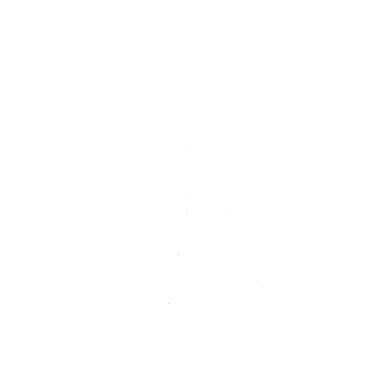

Threshold value: 50


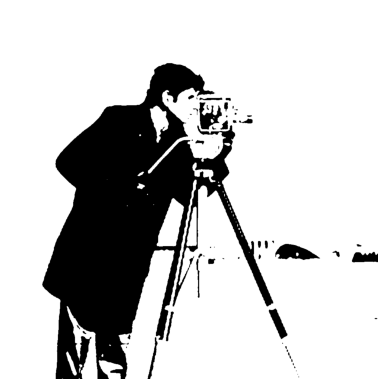

Threshold value: 100


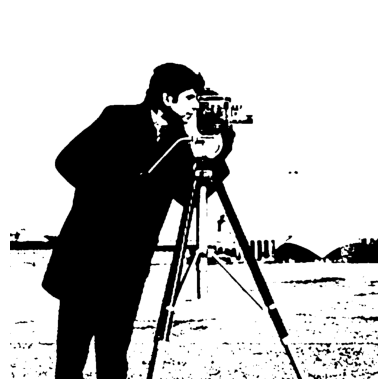

Threshold value: 150


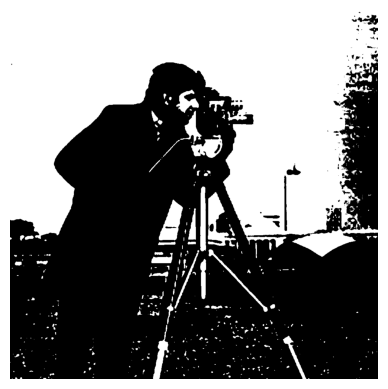

Threshold value: 200


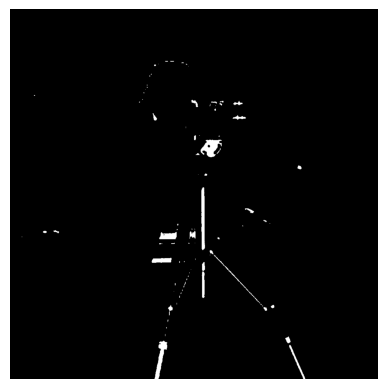

In [3]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('cameraman.png', cv2.IMREAD_GRAYSCALE)
threshold_values = [0, 50, 100, 150, 200]

for threshold_value in threshold_values:
    ret_thresh_value, thresh_img = cv2.threshold(img, threshold_value, 255, cv2.THRESH_BINARY)
    print(f"Threshold value: {threshold_value}")
    plt.imshow(thresh_img, cmap='gray')
    plt.axis('off')
    plt.show()

Original Image: 


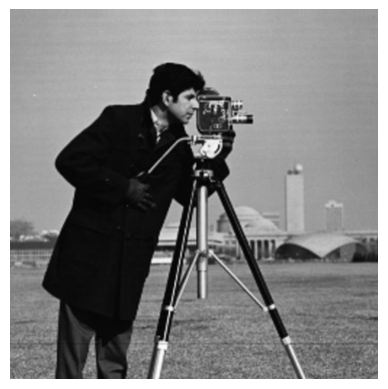

In [5]:
import matplotlib.pyplot as plt

print("Original Image: ")
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

## Histograms

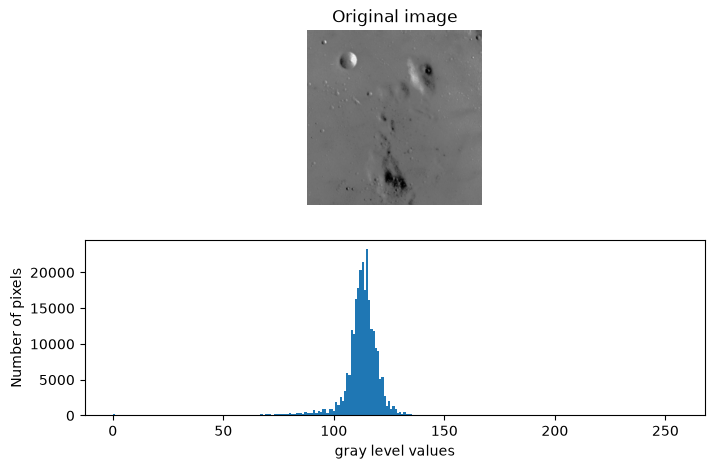

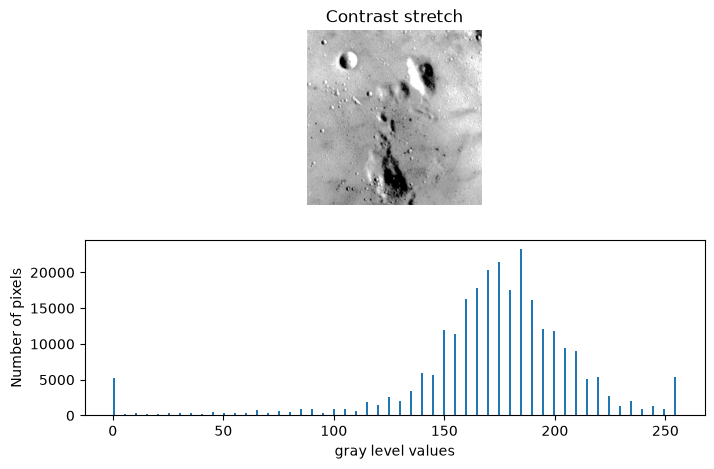

In [9]:
# Task#2: Histogram Processing

# Step#1: Load necessary libraries
import matplotlib
import matplotlib.pyplot as plt
import numpy as np

from skimage import data
from skimage import exposure

# Step#2: Load moon image
img = data.moon()

# Step#3: Rescale intensity values to include all the intensities that fall within the 2nd and 98th percentiles
# Contrast stretching
p2, p98 = np.percentile(img, (2, 98))
img_rescale = exposure.rescale_intensity(img, in_range=(p2, p98))

# Step#4: Display the image with its histogram of (step#2)  and (step#3)
fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img, cmap = 'gray')
plt.axis('off')
plt.title('Original image')

fig.add_subplot(2, 1, 2)
plt.hist(img.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

fig = plt.figure(figsize=(8, 5))
fig.add_subplot(2, 1, 1)
plt.imshow(img_rescale, cmap = 'gray')
plt.axis('off')
plt.title('Contrast stretch')

fig.add_subplot(2, 1, 2)
plt.hist(img_rescale.flat, bins = 256, range=(0, 255))
plt.xlabel('gray level values')
plt.ylabel('Number of pixels')
plt.show()

In [8]:
%pip install scikit-image

  Using cached networkx-3.6.1-py3-none-any.whl.metadata (6.8 kB)
  Using cached imageio-2.37.4-py3-none-any.whl.metadata (9.6 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.1/12.1 MB 776.9 kB/s  0:00:15m0:00:0100:01
Using cached imageio-2.37.4-py3-none-any.whl (318 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached networkx-3.6.1-py3-none-any.whl (2.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.5/20.5 MB 365.0 kB/s  0:01:02m0:00:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [scikit-image] [scikit-image]

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: /Users/albatoolalnasser21/Desktop/image lab/.venv/bin/python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


# Tasks:

Task1: Using the same ‘moon image’ Rescale intensity values to include all the intensities that fall within the 3nd and 80th percentiles, and plot the histogram

Task2: Using the same ‘moon image’ and the exposure.equalize_hist function, display the image and the histogram of the image after flattening the histogram.

Task3: Use the rocket (as reference) and chelsea images (from skimage.data) and implement histogram matching


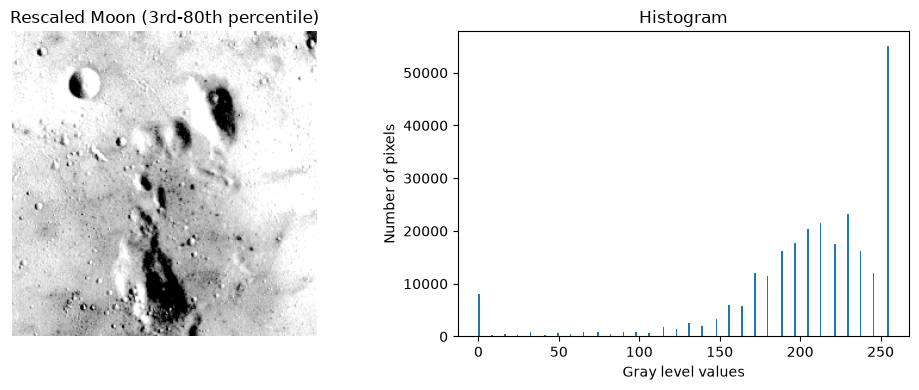

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure

moon_img = data.moon()

p3, p80 = np.percentile(moon_img, (3, 80))
moon_rescaled = exposure.rescale_intensity(moon_img, in_range=(p3, p80))

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(moon_rescaled, cmap='gray')
axes[0].set_title('Rescaled Moon (3rd-80th percentile)')
axes[0].axis('off')

axes[1].hist(moon_rescaled.ravel(), bins=256, range=(0, 255))
axes[1].set_title('Histogram')
axes[1].set_xlabel('Gray level values')
axes[1].set_ylabel('Number of pixels')

plt.tight_layout()
plt.show()

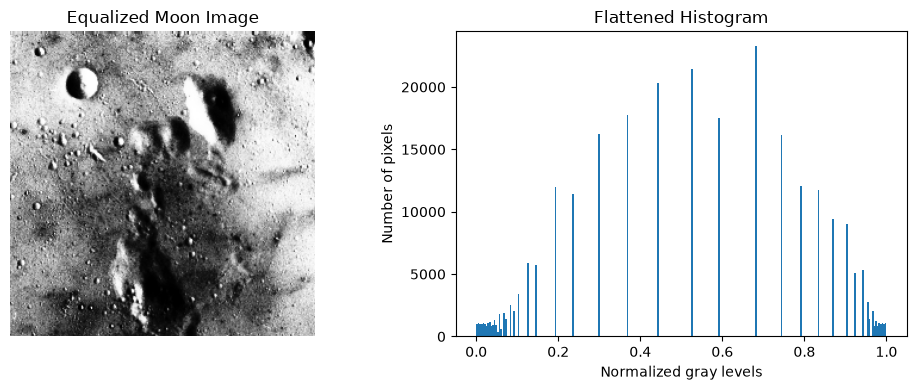

In [11]:
import matplotlib.pyplot as plt
from skimage import data, exposure

moon_img = data.moon()
moon_eq = exposure.equalize_hist(moon_img)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(moon_eq, cmap='gray')
axes[0].set_title('Equalized Moon Image')
axes[0].axis('off')

axes[1].hist(moon_eq.ravel(), bins=256, range=(0, 1))
axes[1].set_title('Flattened Histogram')
axes[1].set_xlabel('Normalized gray levels')
axes[1].set_ylabel('Number of pixels')

plt.tight_layout()
plt.show()

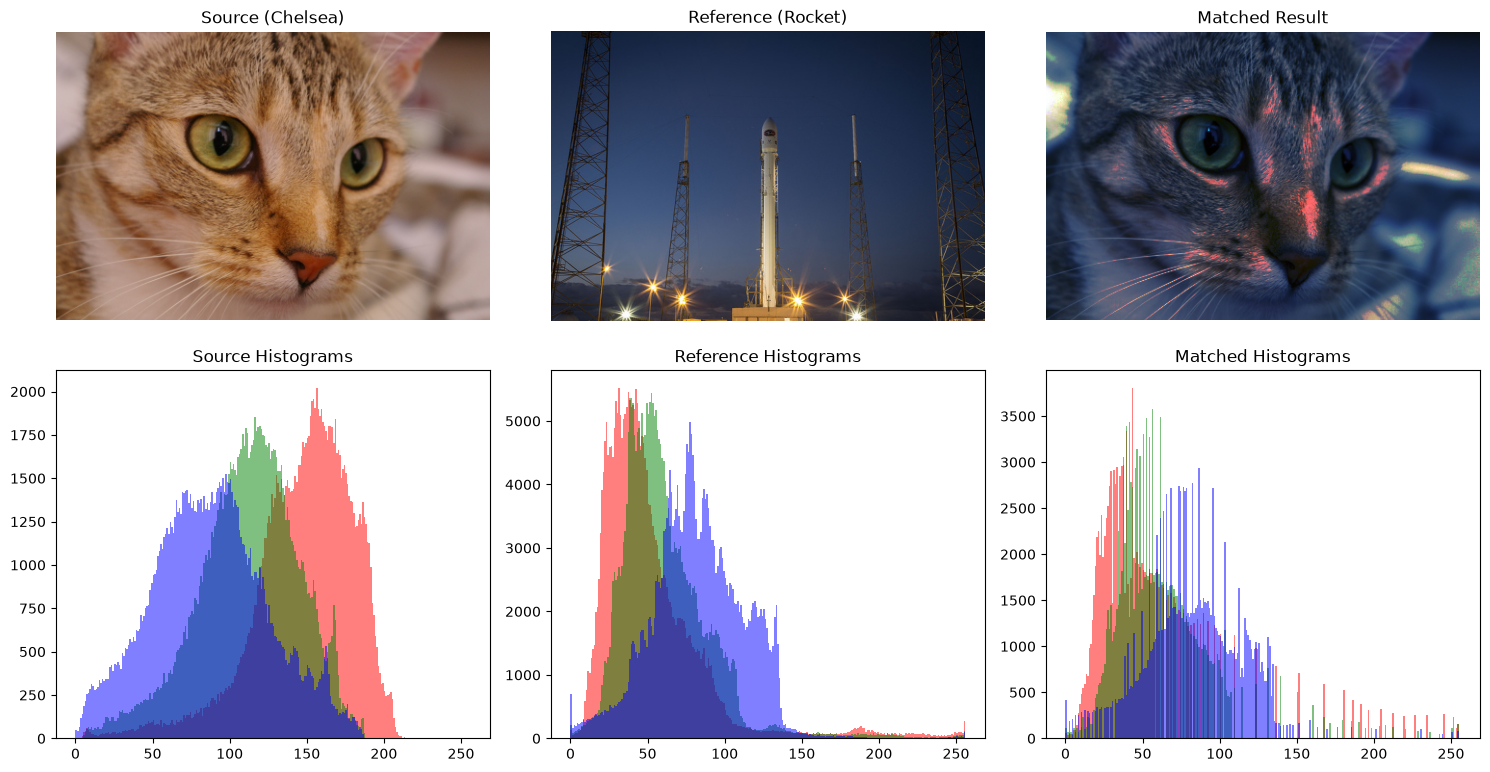

In [12]:
import matplotlib.pyplot as plt
from skimage import data, exposure

ref_img = data.rocket()
src_img = data.chelsea()

matched_img = exposure.match_histograms(src_img, ref_img, channel_axis=-1)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

axes[0, 0].imshow(src_img)
axes[0, 0].set_title('Source (Chelsea)')
axes[0, 0].axis('off')

axes[0, 1].imshow(ref_img)
axes[0, 1].set_title('Reference (Rocket)')
axes[0, 1].axis('off')

axes[0, 2].imshow(matched_img)
axes[0, 2].set_title('Matched Result')
axes[0, 2].axis('off')

for i, (image, title) in enumerate(zip([src_img, ref_img, matched_img], ['Source', 'Reference', 'Matched'])):
    for channel, color in enumerate(['red', 'green', 'blue']):
        axes[1, i].hist(image[:, :, channel].ravel(), bins=256, range=(0, 256), color=color, alpha=0.5)
    axes[1, i].set_title(f'{title} Histograms')

plt.tight_layout()
plt.show()